# **Computer vision model capable of accurately classifying teeth into 7 distinct categories Using Simplified VGG 16 Architecture From Scratch.**

In [1]:
import zipfile
import os

zip_path = "/content/Teeth DataSet.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir("/content/"))

['.config', 'Teeth DataSet.zip', 'Teeth_Dataset', 'sample_data']


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# **Preprocessing(Normalization, Augmentation)**

In [16]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = "/content/Teeth_Dataset/Training"
val_dir   = "/content/Teeth_Dataset/Validation"
test_dir  = "/content/Teeth_Dataset/Testing"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
# Data preprocessing for validation & testing
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


# **Visualize the distribution of the classes**

/tmp/ipython-input-3657819932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="viridis")


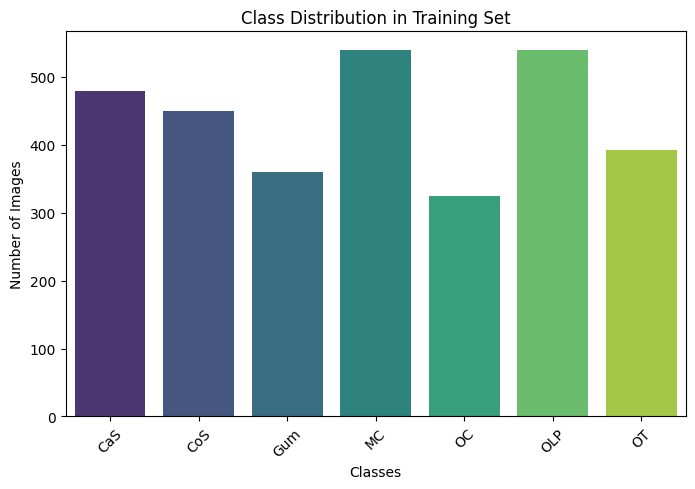

/tmp/ipython-input-3657819932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="viridis")


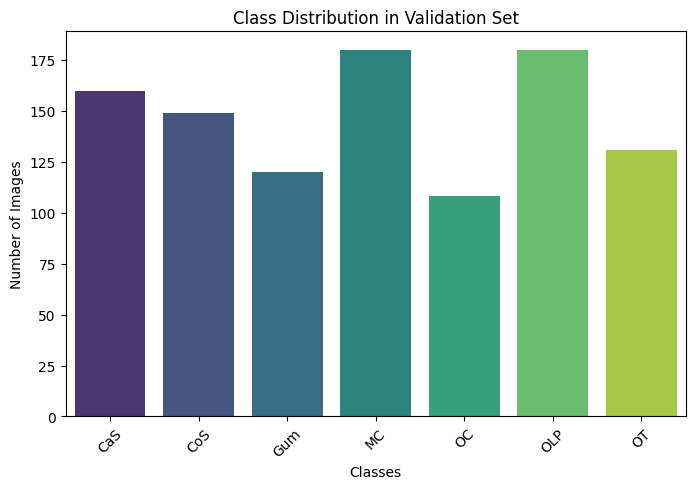

/tmp/ipython-input-3657819932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="viridis")


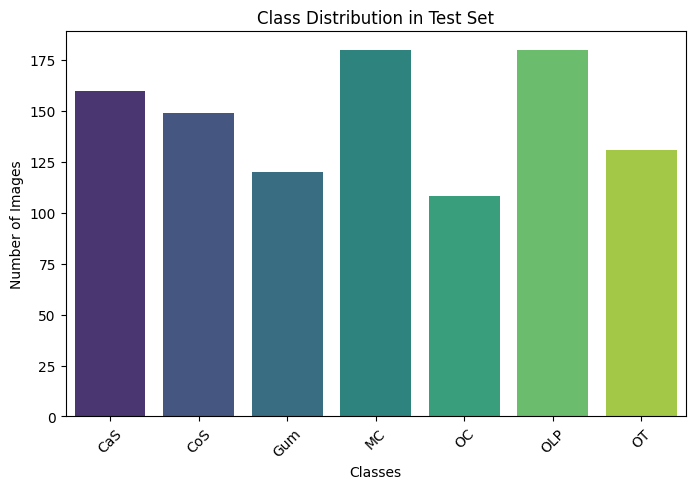

In [17]:
datasets = {
    "Training Set": train_generator,
    "Validation Set": val_generator,
    "Test Set": test_generator
}

for name, gen in datasets.items():
    class_names = list(gen.class_indices.keys())
    labels = gen.classes
    counts = np.bincount(labels)

    plt.figure(figsize=(8,5))
    sns.barplot(x=class_names, y=counts, palette="viridis")
    plt.title(f"Class Distribution in {name}")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.show()

# **Display images before and after augmentation**

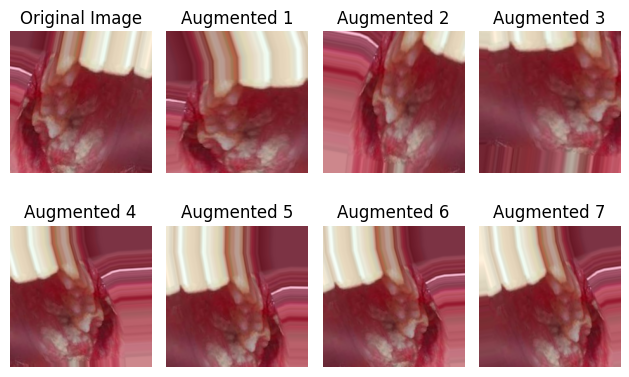

In [18]:
images, labels = next(train_generator)
original_image = images[0]

temp_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

original_image_expanded = np.expand_dims(original_image, axis=0)

plt.subplot(2, 4, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

for i, batch in enumerate(temp_datagen.flow(original_image_expanded, batch_size=1)):
    if i == 7:
        break
    plt.subplot(2, 4, i + 2)
    augmented_image = batch[0]
    plt.imshow(augmented_image)
    plt.title(f'Augmented {i+1}')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Model Architecture and Training**

In [19]:
num_classes = 7

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="best_teeth_model.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [21]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stopping, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.1753 - loss: 2.3043
Epoch 1: val_accuracy improved from -inf to 0.32490, saving model to best_teeth_model.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 411ms/step - accuracy: 0.1757 - loss: 2.3009 - val_accuracy: 0.3249 - val_loss: 1.7076
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.2648 - loss: 1.7932
Epoch 2: val_accuracy improved from 0.32490 to 0.33463, saving model to best_teeth_model.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 392ms/step - accuracy: 0.2649 - loss: 1.7931 - val_accuracy: 0.3346 - val_loss: 1.7280
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3282 - loss: 1.6993
Epoch 3: val_accuracy improved from 0.33463 to 0.42510, saving model to best_teeth_model.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 392ms/step - accuracy: 0.3283 - loss: 1.6991 - val_accuracy: 0.4251 - val_loss: 1.5394
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.3934 - loss: 1.5829
Epoch 4: val_accuracy improved from 0.42510 to 0.43093, saving model to best_teeth_model.h5


...

97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 396ms/step - accuracy: 0.9144 - loss: 0.2716 - val_accuracy: 0.9621 - val_loss: 0.1351
Epoch 68/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9156 - loss: 0.2658
Epoch 68: val_accuracy did not improve from 0.96206
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 395ms/step - accuracy: 0.9155 - loss: 0.2660 - val_accuracy: 0.9533 - val_loss: 0.1733
Epoch 69/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.8939 - loss: 0.3160
Epoch 69: val_accuracy did not improve from 0.96206
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 403ms/step - accuracy: 0.8938 - loss: 0.3163 - val_accuracy: 0.9154 - val_loss: 0.2690
Epoch 70/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8963 - loss: 0.3134
Epoch 70: val_accuracy did not improve from 0.96206
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 409ms/step - accuracy: 0.8963 - loss: 0.3132 - val_accuracy: 0.9183 - val_loss: 0.2459
Epoch 71/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9049 - loss: 0.2854
Epoch 71: val_accura

97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 402ms/step - accuracy: 0.9113 - loss: 0.2541 - val_accuracy: 0.9640 - val_loss: 0.1211
Epoch 76/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9104 - loss: 0.2592
Epoch 76: val_accuracy did not improve from 0.96401
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 399ms/step - accuracy: 0.9104 - loss: 0.2593 - val_accuracy: 0.9621 - val_loss: 0.1381
Epoch 77/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9060 - loss: 0.2730
Epoch 77: val_accuracy did not improve from 0.96401
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 402ms/step - accuracy: 0.9059 - loss: 0.2729 - val_accuracy: 0.9368 - val_loss: 0.1659
Epoch 78/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9088 - loss: 0.2583
Epoch 78: val_accuracy did not improve from 0.96401
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 406ms/step - accuracy: 0.9087 - loss: 0.2586 - val_accuracy: 0.9397 - val_loss: 0.1979
Epoch 79/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9215 - loss: 0.2662
Epoch 79: val_accura

97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 405ms/step - accuracy: 0.9036 - loss: 0.2612 - val_accuracy: 0.9679 - val_loss: 0.1037
Epoch 82/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9278 - loss: 0.2353
Epoch 82: val_accuracy did not improve from 0.96790
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 396ms/step - accuracy: 0.9279 - loss: 0.2351 - val_accuracy: 0.9368 - val_loss: 0.2066
Epoch 83/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9261 - loss: 0.2192
Epoch 83: val_accuracy did not improve from 0.96790
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 396ms/step - accuracy: 0.9261 - loss: 0.2192 - val_accuracy: 0.9397 - val_loss: 0.1806
Epoch 84/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9078 - loss: 0.2567
Epoch 84: val_accuracy did not improve from 0.96790
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 395ms/step - accuracy: 0.9078 - loss: 0.2566 - val_accuracy: 0.9553 - val_loss: 0.1287
Epoch 85/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9151 - loss: 0.2437
Epoch 85: val_accura

97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 419ms/step - accuracy: 0.9360 - loss: 0.1842 - val_accuracy: 0.9767 - val_loss: 0.0760
Epoch 93/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9301 - loss: 0.2176
Epoch 93: val_accuracy did not improve from 0.97665
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 398ms/step - accuracy: 0.9301 - loss: 0.2175 - val_accuracy: 0.9523 - val_loss: 0.1521
Epoch 94/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9270 - loss: 0.2250
Epoch 94: val_accuracy did not improve from 0.97665
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 415ms/step - accuracy: 0.9269 - loss: 0.2251 - val_accuracy: 0.9737 - val_loss: 0.1213
Epoch 95/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9334 - loss: 0.2161
Epoch 95: val_accuracy did not improve from 0.97665
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.9334 - loss: 0.2160 - val_accuracy: 0.9621 - val_loss: 0.1306
Epoch 96/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9307 - loss: 0.2098
Epoch 96: val_accura

97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 411ms/step - accuracy: 0.9388 - loss: 0.1987 - val_accuracy: 0.9786 - val_loss: 0.0760


# **Evaluate The Model**

In [22]:
test_labels = test_generator.classes

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

class_names = list(test_generator.class_indices.keys())

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step


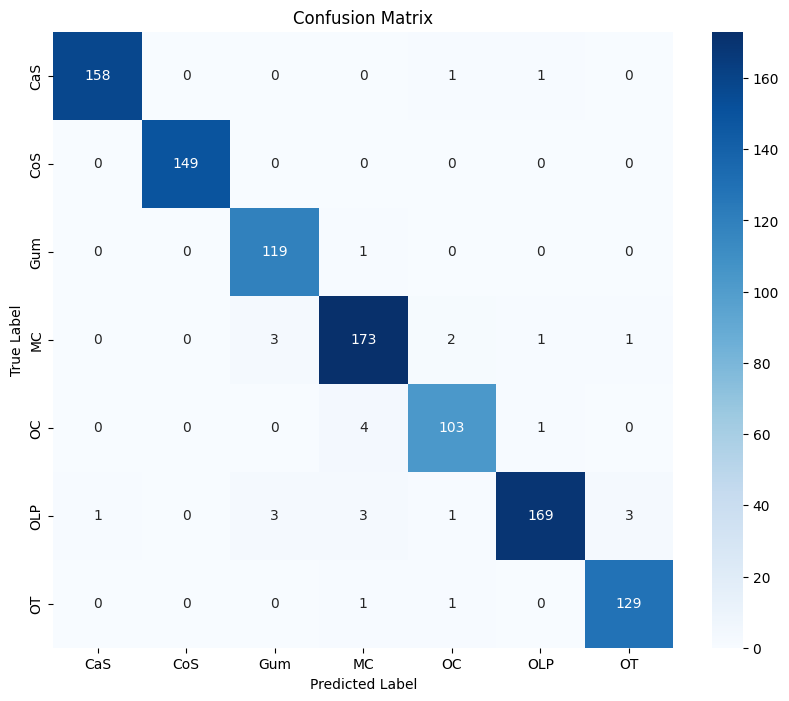

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

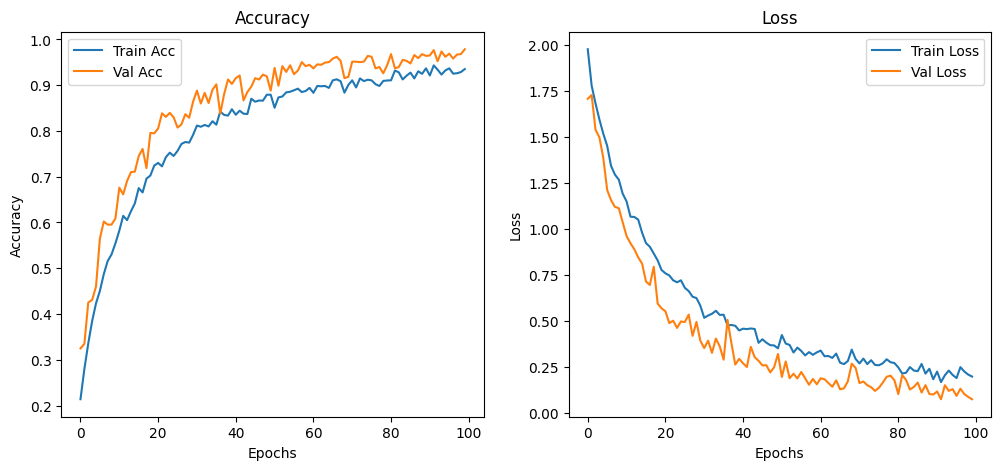

In [24]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_history(history)

In [25]:
print("\nEvaluating the model on the test dataset...")
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")


Evaluating the model on the test dataset...
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9815 - loss: 0.0544

Final Test Loss: 0.0819
Final Test Accuracy: 0.9728
